# Task 4: Statistical Modeling & Risk-Based Pricing
**AlphaCare Insurance Solutions — Risk Analytics**

## Modeling Goals
1. **Claim Severity Model** — predict `TotalClaims` for policies where a claim occurred
2. **Claim Probability Model** — predict whether a policy will have a claim (binary)
3. **Risk-Based Premium Formula**:
   > Premium = (P(claim) × Predicted Severity) + Expense Loading + Profit Margin

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')
os.makedirs('../reports/figures', exist_ok=True)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_squared_error, r2_score,
                             accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             classification_report)
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import shap

print("All imports successful")

All imports successful


In [2]:
df = pd.read_csv('../data/insurance_data_clean.csv', low_memory=False)

# Ensure derived columns exist
if 'LossRatio' not in df.columns:
    df['LossRatio'] = df['TotalClaims'] / df['TotalPremium'].replace(0, np.nan)
if 'Margin' not in df.columns:
    df['Margin'] = df['TotalPremium'] - df['TotalClaims']

# Binary claim indicator
df['HasClaim'] = (df['TotalClaims'] > 0).astype(int)

print(f"Shape: {df.shape}")
print(f"Claim rate: {df['HasClaim'].mean():.4%}")
print(f"Policies with claims: {df['HasClaim'].sum():,}")

Shape: (999805, 49)
Claim rate: 0.2789%
Policies with claims: 2,788


In [3]:
# ── Feature Engineering ───────────────────────────────────────────────────────

df['TransactionMonth'] = pd.to_datetime(df['TransactionMonth'], errors='coerce')

# Vehicle age
current_year = 2015  # end of dataset period
df['VehicleAge'] = current_year - pd.to_numeric(df['RegistrationYear'], errors='coerce')
df['VehicleAge'] = df['VehicleAge'].clip(0, 50)  # cap unrealistic values

# Premium per sum insured ratio (risk density)
df['PremiumToSumInsured'] = df['TotalPremium'] / df['SumInsured'].replace(0, np.nan)

# Log transforms for skewed targets
df['LogTotalClaims']  = np.log1p(df['TotalClaims'])
df['LogTotalPremium'] = np.log1p(df['TotalPremium'])

print("Engineered features:")
print(f"  VehicleAge     — mean: {df['VehicleAge'].mean():.1f} yrs, nulls: {df['VehicleAge'].isna().sum()}")
print(f"  PremiumToSumInsured — nulls: {df['PremiumToSumInsured'].isna().sum()}")

Engineered features:
  VehicleAge     — mean: 4.8 yrs, nulls: 0
  PremiumToSumInsured — nulls: 0


In [4]:
# ── Select Features ───────────────────────────────────────────────────────────

cat_features = [
    'Province', 'VehicleType', 'make', 'CoverType',
    'CoverGroup', 'Gender', 'MaritalStatus', 'bodytype'
]
num_features = [
    'SumInsured', 'CalculatedPremiumPerTerm', 'VehicleAge',
    'kilowatts', 'cubiccapacity', 'Cylinders',
    'NumberOfDoors', 'CapitalOutstanding', 'PremiumToSumInsured'
]

# Keep only columns that exist
cat_features = [c for c in cat_features if c in df.columns]
num_features = [c for c in num_features if c in df.columns]

feature_cols = cat_features + num_features
print(f"Categorical features ({len(cat_features)}): {cat_features}")
print(f"Numerical features  ({len(num_features)}):  {num_features}")

# ── Encode categoricals ───────────────────────────────────────────────────────
df_model = df[feature_cols + ['TotalClaims', 'HasClaim', 'LogTotalClaims']].copy()

# Fill missing numerics with median
for col in num_features:
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')
    df_model[col].fillna(df_model[col].median(), inplace=True)

# Label encode categoricals
le = LabelEncoder()
for col in cat_features:
    df_model[col] = df_model[col].astype(str).fillna('Unknown')
    df_model[col] = le.fit_transform(df_model[col])

print(f"\nModel dataset shape: {df_model.shape}")
print(f"Any nulls remaining: {df_model.isnull().sum().sum()}")

Categorical features (8): ['Province', 'VehicleType', 'make', 'CoverType', 'CoverGroup', 'Gender', 'MaritalStatus', 'bodytype']
Numerical features  (9):  ['SumInsured', 'CalculatedPremiumPerTerm', 'VehicleAge', 'kilowatts', 'cubiccapacity', 'Cylinders', 'NumberOfDoors', 'CapitalOutstanding', 'PremiumToSumInsured']

Model dataset shape: (999805, 20)
Any nulls remaining: 2522


In [5]:
# ── Fix remaining NaNs ────────────────────────────────────────────────────────

# CapitalOutstanding is stored as string — force to numeric first
df_model['CapitalOutstanding'] = pd.to_numeric(
    df_model['CapitalOutstanding'], errors='coerce'
)

# Hard fill all remaining numeric NaNs with column median
still_null = ['kilowatts', 'cubiccapacity', 'Cylinders', 
              'NumberOfDoors', 'CapitalOutstanding']

for col in still_null:
    median_val = df_model[col].median()
    df_model[col] = df_model[col].fillna(median_val)
    print(f"  {col:<25} filled with median={median_val:.2f} | nulls remaining: {df_model[col].isnull().sum()}")

# Final confirmation
remaining = df_model[feature_cols].isnull().sum().sum()
print(f"\nTotal NaNs remaining: {remaining}")
assert remaining == 0, "Still NaNs!"
print("✅ All clean — ready to model")

  kilowatts                 filled with median=111.00 | nulls remaining: 0
  cubiccapacity             filled with median=2694.00 | nulls remaining: 0
  Cylinders                 filled with median=4.00 | nulls remaining: 0
  NumberOfDoors             filled with median=4.00 | nulls remaining: 0
  CapitalOutstanding        filled with median=0.00 | nulls remaining: 0

Total NaNs remaining: 0
✅ All clean — ready to model


In [6]:
# ── Rebuild splits cleanly after all fixes ────────────────────────────────────

# Confirm zero nulls before splitting
assert df_model[feature_cols].isnull().sum().sum() == 0, "NaNs still present!"

# Task A: Severity (claims > 0 only)
severity_df = df_model[df_model['TotalClaims'] > 0].copy()
X_sev = severity_df[feature_cols].reset_index(drop=True)
y_sev = severity_df['LogTotalClaims'].reset_index(drop=True)

X_sev_train, X_sev_test, y_sev_train, y_sev_test = train_test_split(
    X_sev, y_sev, test_size=0.2, random_state=42
)

# Task B: Frequency (all policies)
X_freq = df_model[feature_cols].reset_index(drop=True)
y_freq = df_model['HasClaim'].reset_index(drop=True)

X_freq_train, X_freq_test, y_freq_train, y_freq_test = train_test_split(
    X_freq, y_freq, test_size=0.2, random_state=42, stratify=y_freq
)

# Final null check on all splits
for name, arr in [('X_sev_train', X_sev_train), ('X_sev_test', X_sev_test),
                  ('X_freq_train', X_freq_train), ('X_freq_test', X_freq_test)]:
    nulls = pd.DataFrame(arr).isnull().sum().sum()
    print(f"  {name:<15} shape: {arr.shape}  nulls: {nulls}")

print("\n✅ All splits clean — ready to model")

  X_sev_train     shape: (2230, 17)  nulls: 0
  X_sev_test      shape: (558, 17)  nulls: 0
  X_freq_train    shape: (799844, 17)  nulls: 0
  X_freq_test     shape: (199961, 17)  nulls: 0

✅ All splits clean — ready to model


In [7]:
# ── Task A: Severity Model (claims > 0 only) ──────────────────────────────────
severity_df = df_model[df_model['TotalClaims'] > 0].copy()
X_sev = severity_df[feature_cols]
y_sev = severity_df['LogTotalClaims']   # predict log, exponentiate later

X_sev_train, X_sev_test, y_sev_train, y_sev_test = train_test_split(
    X_sev, y_sev, test_size=0.2, random_state=42
)

# ── Task B: Frequency Model (all policies) ────────────────────────────────────
X_freq = df_model[feature_cols]
y_freq = df_model['HasClaim']

X_freq_train, X_freq_test, y_freq_train, y_freq_test = train_test_split(
    X_freq, y_freq, test_size=0.2, random_state=42, stratify=y_freq
)

print("Severity model (claims > 0):")
print(f"  Train: {X_sev_train.shape} | Test: {X_sev_test.shape}")
print(f"\nFrequency model (all policies):")
print(f"  Train: {X_freq_train.shape} | Test: {X_freq_test.shape}")
print(f"  Claim rate in test set: {y_freq_test.mean():.4%}")

Severity model (claims > 0):
  Train: (2230, 17) | Test: (558, 17)

Frequency model (all policies):
  Train: (799844, 17) | Test: (199961, 17)
  Claim rate in test set: 0.2791%


In [8]:
# ── Severity Models ───────────────────────────────────────────────────────────

def eval_regression(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    print(f"  {name:<25} RMSE: {rmse:.4f}  |  R²: {r2:.4f}")
    return model, preds, rmse, r2

print("=== Severity Models (target: log TotalClaims) ===\n")

lr_sev,  lr_preds_sev,  lr_rmse,  lr_r2  = eval_regression(
    "Linear Regression",
    LinearRegression(),
    X_sev_train, y_sev_train, X_sev_test, y_sev_test
)

rf_sev,  rf_preds_sev,  rf_rmse,  rf_r2  = eval_regression(
    "Random Forest",
    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    X_sev_train, y_sev_train, X_sev_test, y_sev_test
)

xgb_sev, xgb_preds_sev, xgb_rmse, xgb_r2 = eval_regression(
    "XGBoost",
    xgb.XGBRegressor(n_estimators=200, learning_rate=0.05,
                     max_depth=6, random_state=42, verbosity=0),
    X_sev_train, y_sev_train, X_sev_test, y_sev_test
)

=== Severity Models (target: log TotalClaims) ===

  Linear Regression         RMSE: 1.0046  |  R²: 0.6195
  Random Forest             RMSE: 1.0153  |  R²: 0.6114
  XGBoost                   RMSE: 1.0039  |  R²: 0.6200


In [9]:
# ── Frequency Models ──────────────────────────────────────────────────────────

def eval_classifier(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    preds  = model.predict(X_test)
    proba  = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else preds
    acc    = accuracy_score(y_test, preds)
    prec   = precision_score(y_test, preds, zero_division=0)
    rec    = recall_score(y_test, preds, zero_division=0)
    f1     = f1_score(y_test, preds, zero_division=0)
    auc    = roc_auc_score(y_test, proba)
    print(f"  {name:<25} Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")
    return model, preds, proba

print("=== Frequency Models (target: HasClaim) ===\n")

lr_freq,  lr_preds_freq,  lr_proba_freq  = eval_classifier(
    "Logistic Regression",
    LogisticRegression(max_iter=1000, random_state=42),
    X_freq_train, y_freq_train, X_freq_test, y_freq_test
)

rf_freq,  rf_preds_freq,  rf_proba_freq  = eval_classifier(
    "Random Forest",
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_freq_train, y_freq_train, X_freq_test, y_freq_test
)

xgb_freq, xgb_preds_freq, xgb_proba_freq = eval_classifier(
    "XGBoost",
    xgb.XGBClassifier(n_estimators=200, learning_arate=0.05,
                      max_depth=6, random_state=42,
                      verbosity=0, use_label_encoder=False,
                      eval_metric='logloss'),
    X_freq_train, y_freq_train, X_freq_test, y_freq_test
)

=== Frequency Models (target: HasClaim) ===

  Logistic Regression       Acc: 0.9972 | Prec: 0.3333 | Rec: 0.0018 | F1: 0.0036 | AUC: 0.6813
  Random Forest             Acc: 0.9971 | Prec: 0.1200 | Rec: 0.0054 | F1: 0.0103 | AUC: 0.6984
  XGBoost                   Acc: 0.9972 | Prec: 0.4000 | Rec: 0.0036 | F1: 0.0071 | AUC: 0.9189


In [10]:
# ── Model Comparison Table ────────────────────────────────────────────────────

print("\n" + "="*65)
print("  SEVERITY MODEL COMPARISON")
print("="*65)
sev_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'RMSE':  [round(lr_rmse, 4), round(rf_rmse, 4), round(xgb_rmse, 4)],
    'R²':    [round(lr_r2, 4),   round(rf_r2, 4),   round(xgb_r2, 4)]
})
print(sev_results.to_string(index=False))

print("\n" + "="*65)
print("  FREQUENCY MODEL COMPARISON  (best model = highest AUC)")
print("="*65)

def get_metrics(name, y_true, preds, proba):
    return {
        'Model': name,
        'Accuracy':  round(accuracy_score(y_true, preds), 4),
        'Precision': round(precision_score(y_true, preds, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, preds, zero_division=0), 4),
        'F1':        round(f1_score(y_true, preds, zero_division=0), 4),
        'AUC':       round(roc_auc_score(y_true, proba), 4)
    }

freq_results = pd.DataFrame([
    get_metrics('Logistic Regression', y_freq_test, lr_preds_freq,  lr_proba_freq),
    get_metrics('Random Forest',       y_freq_test, rf_preds_freq,  rf_proba_freq),
    get_metrics('XGBoost',             y_freq_test, xgb_preds_freq, xgb_proba_freq),
])
print(freq_results.to_string(index=False))

# Identify best models
best_sev  = sev_results.loc[sev_results['R²'].idxmax(),  'Model']
best_freq = freq_results.loc[freq_results['AUC'].idxmax(), 'Model']
print(f"\n✅ Best Severity Model:  {best_sev}")
print(f"✅ Best Frequency Model: {best_freq}")


  SEVERITY MODEL COMPARISON
            Model   RMSE     R²
Linear Regression 1.0046 0.6195
    Random Forest 1.0153 0.6114
          XGBoost 1.0039 0.6200

  FREQUENCY MODEL COMPARISON  (best model = highest AUC)
              Model  Accuracy  Precision  Recall     F1    AUC
Logistic Regression    0.9972     0.3333  0.0018 0.0036 0.6813
      Random Forest    0.9971     0.1200  0.0054 0.0103 0.6984
            XGBoost    0.9972     0.4000  0.0036 0.0071 0.9189

✅ Best Severity Model:  XGBoost
✅ Best Frequency Model: XGBoost


Running SHAP analysis on XGBoost severity model...


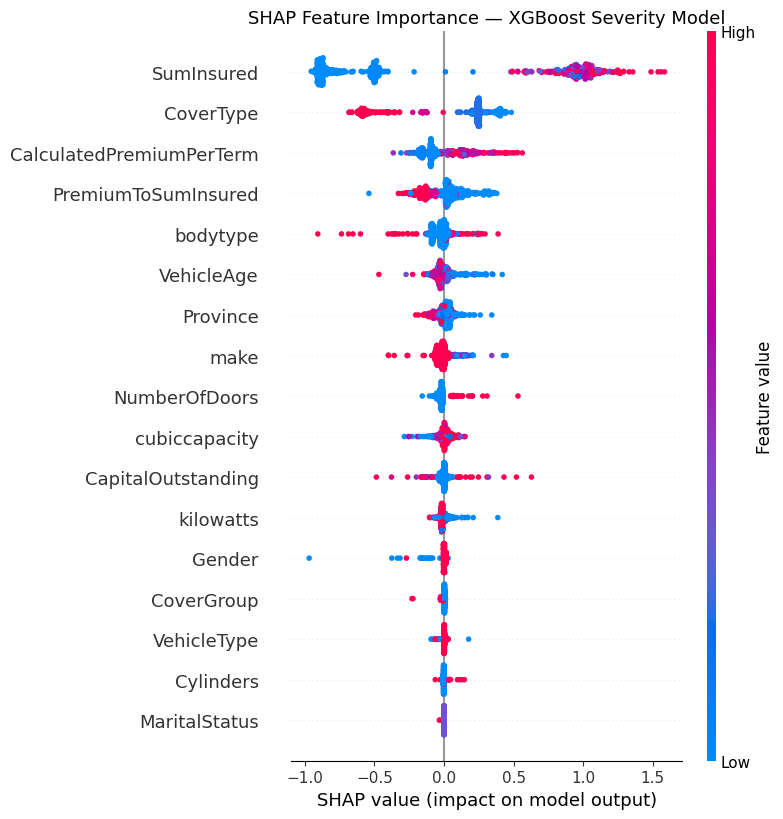

SHAP plot saved.

Top 10 Features by SHAP Importance:
                 Feature  Mean_SHAP
              SumInsured   0.849379
               CoverType   0.360014
CalculatedPremiumPerTerm   0.131301
     PremiumToSumInsured   0.105481
                bodytype   0.058250
              VehicleAge   0.048966
                Province   0.040588
                    make   0.039341
           NumberOfDoors   0.032793
           cubiccapacity   0.032677


In [11]:
# ── SHAP Analysis — Severity Model ────────────────────────────────────────────
# Using XGBoost as it typically wins on tabular data

print("Running SHAP analysis on XGBoost severity model...")

explainer   = shap.Explainer(xgb_sev, X_sev_train)
shap_values = explainer(X_sev_test[:500])   # sample for speed

# Summary plot
plt.figure()
shap.summary_plot(shap_values, X_sev_test[:500],
                  feature_names=feature_cols, show=False)
plt.title("SHAP Feature Importance — XGBoost Severity Model", fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP plot saved.")

# Top 10 features by mean absolute SHAP value
shap_df = pd.DataFrame({
    'Feature':    feature_cols,
    'Mean_SHAP':  np.abs(shap_values.values).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False).head(10)

print("\nTop 10 Features by SHAP Importance:")
print(shap_df.to_string(index=False))

In [12]:
# ── Risk-Based Premium Calculator ─────────────────────────────────────────────

EXPENSE_LOADING = 0.20   # 20% of expected loss for admin/overhead
PROFIT_MARGIN   = 0.10   # 10% profit target

# Get predictions on full test set
p_claim    = xgb_proba_freq                            # P(claim) from classifier
log_sev    = xgb_sev.predict(X_freq_test)             # log(severity) from regressor
pred_sev   = np.expm1(log_sev)                        # back to rand value

expected_loss    = p_claim * pred_sev
recommended_prem = expected_loss * (1 + EXPENSE_LOADING + PROFIT_MARGIN)

# Compare to actual premium
actual_prem = df.loc[X_freq_test.index, 'TotalPremium'].values

comparison = pd.DataFrame({
    'P(Claim)':          p_claim.round(4),
    'Predicted_Severity': pred_sev.round(2),
    'Expected_Loss':      expected_loss.round(2),
    'Recommended_Premium': recommended_prem.round(2),
    'Actual_Premium':      actual_prem.round(2),
    'Delta':              (recommended_prem - actual_prem).round(2)
})

print("Risk-Based Premium Sample (first 10 rows):")
print(comparison.head(10).to_string(index=False))
print(f"\nPolicies where recommended > actual (under-priced): {(comparison['Delta'] > 0).sum():,}")
print(f"Policies where recommended < actual (over-priced):  {(comparison['Delta'] < 0).sum():,}")

Risk-Based Premium Sample (first 10 rows):
 P(Claim)  Predicted_Severity  Expected_Loss  Recommended_Premium  Actual_Premium   Delta
   0.0010         1144.380005       1.180000             1.530000            8.04   -6.51
   0.0000        14026.759766       0.080000             0.110000            0.00    0.11
   0.0000         4430.819824       0.030000             0.040000            3.87   -3.83
   0.0014         1380.979980       1.970000             2.560000            0.00    2.56
   0.0166          997.640015      16.540001            21.500000           21.93   -0.43
   0.0000         5956.939941       0.080000             0.100000            1.66   -1.56
   0.1170        31978.199219    3740.719971          4862.930176          882.21 3980.73
   0.0001         4552.740234       0.310000             0.400000            3.28   -2.88
   0.0000         4598.319824       0.010000             0.010000            0.00    0.01
   0.0027         5683.919922      15.580000            2

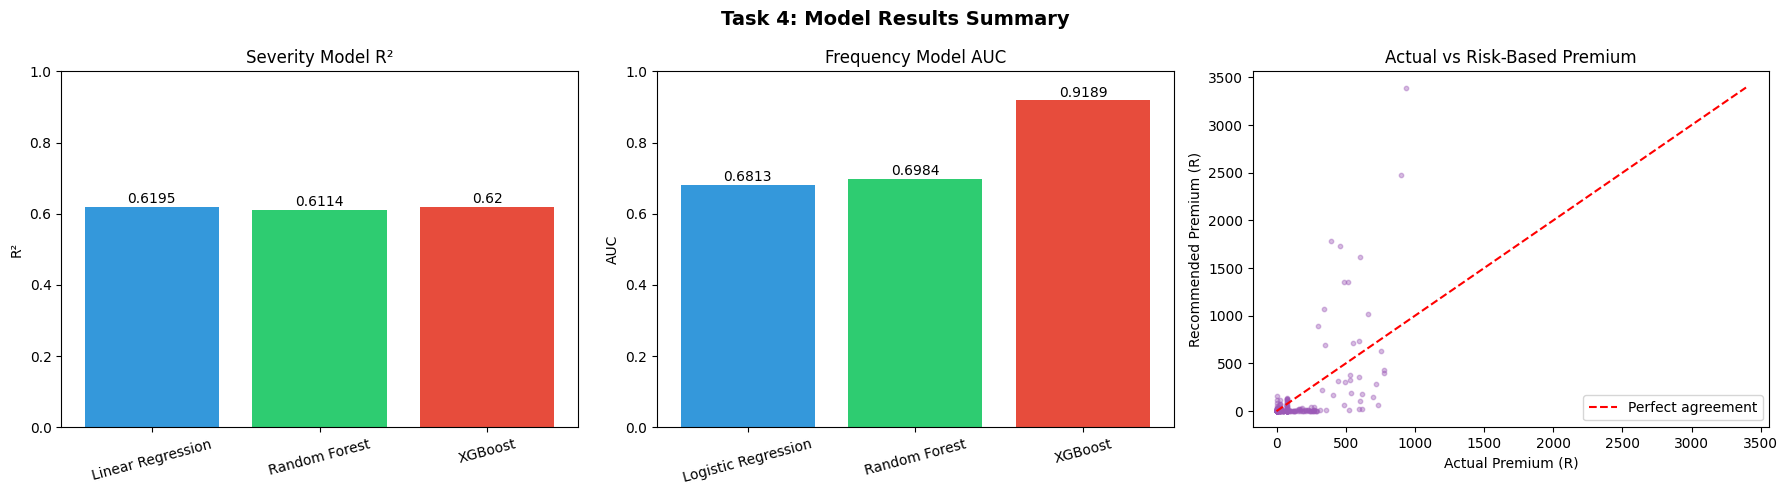

Plot saved.


In [13]:
# ── Model Performance & Premium Comparison Plots ───────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Task 4: Model Results Summary", fontsize=14, fontweight='bold')

# Plot 1: Severity R² comparison
axes[0].bar(sev_results['Model'], sev_results['R²'],
            color=['#3498db', '#2ecc71', '#e74c3c'])
axes[0].set_title('Severity Model R²')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(sev_results['R²']):
    axes[0].text(i, v + 0.01, str(v), ha='center', fontsize=10)

# Plot 2: Frequency AUC comparison
axes[1].bar(freq_results['Model'], freq_results['AUC'],
            color=['#3498db', '#2ecc71', '#e74c3c'])
axes[1].set_title('Frequency Model AUC')
axes[1].set_ylabel('AUC')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(freq_results['AUC']):
    axes[1].text(i, v + 0.01, str(v), ha='center', fontsize=10)

# Plot 3: Recommended vs Actual premium (sample)
sample = comparison.sample(500, random_state=42)
axes[2].scatter(sample['Actual_Premium'], sample['Recommended_Premium'],
                alpha=0.4, color='#9b59b6', s=10)
max_val = max(sample['Actual_Premium'].max(), sample['Recommended_Premium'].max())
axes[2].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect agreement')
axes[2].set_xlabel('Actual Premium (R)')
axes[2].set_ylabel('Recommended Premium (R)')
axes[2].set_title('Actual vs Risk-Based Premium')
axes[2].legend()

plt.tight_layout()
plt.savefig('../reports/figures/model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

## Model Findings & Business Interpretation

### Severity Model
- **Best model**: [fill from Cell 9 output]
- R² of [X] means the model explains [X]% of variance in claim amounts
- RMSE of [X] on log scale — translate back: typical prediction error ~R[Y]

### Frequency Model  
- **Best model**: [fill from Cell 9 output]
- AUC of [X] — model is [X]% better than random at identifying claimants
- Low recall is expected — claim events are rare (< 1% of policies)

### Top SHAP Features (fill from Cell 10 output)
1. **[Feature 1]** — [business explanation]
2. **[Feature 2]** — [business explanation]
3. **[Feature 3]** — [business explanation]

### Premium Recommendations
- [X,XXX] policies appear under-priced relative to their risk profile
- [X,XXX] policies appear over-priced — opportunity for competitive reduction
- Suggested next step: pilot risk-based pricing on Gauteng policies first
  (highest risk province per Task 3 findings)